# Bengaluru Strategic Logistics Optimizer (BSLO)
## Part 1: Exploratory Data Analysis & Data Cleaning

**Dataset:** [Bangalore City Traffic Dataset](https://www.kaggle.com/datasets/preethamgouda/banglore-city-traffic-dataset)

---

### Objective
This notebook performs exploratory data analysis (EDA) and data cleaning on the Bangalore Traffic Dataset to prepare it for building a predictive model that forecasts **Congestion Level** (Friction Score) and **Environmental Impact** for day-ahead route planning.

### Table of Contents
1. [Setup and Data Loading](#1-setup-and-data-loading)
2. [Initial Data Inspection](#2-initial-data-inspection)
3. [Data Cleaning](#3-data-cleaning)
4. [Univariate Analysis](#4-univariate-analysis)
5. [Bivariate Analysis](#5-bivariate-analysis)
6. [Temporal Analysis](#6-temporal-analysis)
7. [Outlier Analysis](#7-outlier-analysis)
8. [Feature Engineering](#8-feature-engineering)
9. [Correlation Analysis](#9-correlation-analysis)
10. [Summary and Next Steps](#10-summary-and-next-steps)

---
## 1. Setup and Data Loading <a id='1-setup-and-data-loading'></a>

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot settings
FIGSIZE = (12, 6)
TITLE_FONTSIZE = 14
LABEL_FONTSIZE = 12

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
DATA_PATH = '../data/Banglore_traffic_Dataset.csv'
df_raw = pd.read_csv(DATA_PATH)

# Create a working copy
df = df_raw.copy()

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 8,936 rows × 16 columns


---
## 2. Initial Data Inspection <a id='2-initial-data-inspection'></a>

In [3]:
# Display first few rows
df.head()

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.23,1.50,100.00,100.00,0,151.18,70.63,84.04,85.40,111,Clear,No
1,2022-01-01,Indiranagar,CMH Road,30825,29.38,1.50,100.00,100.00,1,111.65,41.92,91.41,59.98,100,Clear,No
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.47,1.04,28.35,36.40,0,64.80,44.66,61.38,95.47,189,Clear,No
3,2022-01-01,Koramangala,Sony World Junction,60874,43.82,1.50,100.00,100.00,1,171.75,32.77,75.55,63.57,111,Clear,No
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.12,1.50,100.00,100.00,3,164.58,35.09,64.63,93.16,104,Clear,No


In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8936 entries, 0 to 8935
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Date                                8936 non-null   str    
 1   Area Name                           8936 non-null   str    
 2   Road/Intersection Name              8936 non-null   str    
 3   Traffic Volume                      8936 non-null   int64  
 4   Average Speed                       8936 non-null   float64
 5   Travel Time Index                   8936 non-null   float64
 6   Congestion Level                    8936 non-null   float64
 7   Road Capacity Utilization           8936 non-null   float64
 8   Incident Reports                    8936 non-null   int64  
 9   Environmental Impact                8936 non-null   float64
 10  Public Transport Usage              8936 non-null   float64
 11  Traffic Signal Compliance           8936 non-null   fl

In [5]:
# Statistical summary for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Traffic Volume,8936.00,29236.05,13001.81,4233.00,19413.00,27600.00,38058.50,72039.00
Average Speed,8936.00,39.45,10.71,20.00,31.78,39.20,46.64,89.79
Travel Time Index,8936.00,1.38,0.17,1.00,1.24,1.50,1.50,1.50
Congestion Level,8936.00,80.82,23.53,5.16,64.29,92.39,100.00,100.00
Road Capacity Utilization,8936.00,92.03,16.58,18.74,97.35,100.00,100.00,100.00
Incident Reports,8936.00,1.57,1.42,0.00,0.00,1.00,2.00,10.00
Environmental Impact,8936.00,108.47,26.00,58.47,88.83,105.20,126.12,194.08
Public Transport Usage,8936.00,45.09,20.21,10.01,27.34,45.17,62.43,79.98
Traffic Signal Compliance,8936.00,79.95,11.59,60.00,69.83,79.99,89.96,99.99
Parking Usage,8936.00,75.16,14.41,50.02,62.55,75.32,87.52,100.00


In [6]:
# Check unique values per column
unique_counts = pd.DataFrame({
    'Column': df.columns,
    'Unique Values': df.nunique().values,
    'Data Type': df.dtypes.values,
    'Sample Values': [df[col].dropna().unique()[:3].tolist() for col in df.columns]
})
unique_counts

,Column,Unique Values,Data Type,Sample Values
0,Date,952,str,"[2022-01-01, 2022-01-02, 2022-01-03]"
1,Area Name,8,str,"[Indiranagar, Whitefield, Koramangala]"
2,Road/Intersection Name,16,str,"[100 Feet Road, CMH Road, Marathahalli Bridge]"
3,Traffic Volume,8100,int64,"[50590, 30825, 7399]"
4,Average Speed,8572,float64,"[50.23029856408026, 29.377124707590273, 54.474..."
5,Travel Time Index,3711,float64,"[1.5, 1.0390688456025536, 1.3548345697060469]"
6,Congestion Level,5053,float64,"[100.0, 28.34799386357647, 79.03882287608127]"
7,Road Capacity Utilization,2352,float64,"[100.0, 36.39652493739601, 76.63531646154289]"
8,Incident Reports,11,int64,"[0, 1, 3]"
9,Environmental Impact,8100,float64,"[151.18, 111.65, 64.798]"


### Key Observations from Initial Inspection
- **Date Range:** Data spans from January 2022 to August 2024
- **Granularity:** Daily aggregated traffic data per road/intersection
- **Geographic Coverage:** 8 areas, 16 roads/intersections in Bangalore
- **Target Variables:** `Congestion Level` (0-100) and `Environmental Impact`

---
## 3. Data Cleaning <a id='3-data-cleaning'></a>

### 3.1 Missing Values Analysis

In [7]:
# Check for missing values
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
})
missing_df[missing_df['Missing Count'] > 0]

,Column,Missing Count,Missing Percentage


In [ ]:
# Define numerical columns for analysis
numerical_cols = ['Traffic Volume', 'Average Speed', 'Travel Time Index', 
                  'Congestion Level', 'Road Capacity Utilization', 'Incident Reports',
                  'Environmental Impact', 'Public Transport Usage', 
                  'Traffic Signal Compliance', 'Parking Usage', 'Pedestrian and Cyclist Count']

# Distribution plots for key numerical variables
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

# Generate color palette
colors = sns.color_palette('husl', len(numerical_cols))

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    sns.histplot(df[col], kde=True, ax=ax, color=colors[idx])
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
    # Add mean and median lines
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='green', linestyle=':', linewidth=1.5, label=f'Median: {df[col].median():.1f}')
    ax.legend(fontsize=8)

# Hide empty subplot
axes[-1].axis('off')

plt.suptitle('Distribution of Numerical Variables', fontsize=TITLE_FONTSIZE, y=1.02)
plt.tight_layout()
plt.show()

✓ No missing values detected in the dataset.


### 3.2 Duplicate Records Analysis

In [9]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

# Check for duplicate Date + Road combinations (should be unique)
duplicate_keys = df.duplicated(subset=['Date', 'Road/Intersection Name']).sum()
print(f"Duplicate Date + Road combinations: {duplicate_keys}")

if duplicate_count > 0:
    print(f"\nRemoving {duplicate_count} duplicate rows...")
    df = df.drop_duplicates()
    print(f"New shape: {df.shape}")
else:
    print("✓ No duplicate records found.")

Total duplicate rows: 0
Duplicate Date + Road combinations: 0
✓ No duplicate records found.


### 3.3 Data Type Corrections

In [10]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Convert categorical columns to category dtype for memory efficiency
categorical_cols = ['Area Name', 'Road/Intersection Name', 'Weather Conditions', 
                    'Roadwork and Construction Activity']

for col in categorical_cols:
    df[col] = df[col].astype('category')

print("Data types after conversion:")
df.dtypes

Data types after conversion:


Date                                  datetime64[us]
Area Name                                   category
Road/Intersection Name                      category
Traffic Volume                                 int64
Average Speed                                float64
Travel Time Index                            float64
Congestion Level                             float64
Road Capacity Utilization                    float64
Incident Reports                               int64
Environmental Impact                         float64
Public Transport Usage                       float64
Traffic Signal Compliance                    float64
Parking Usage                                float64
Pedestrian and Cyclist Count                   int64
Weather Conditions                          category
Roadwork and Construction Activity          category
dtype: object

In [11]:
# Verify date range
print(f"Date Range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Total Days Covered: {(df['Date'].max() - df['Date'].min()).days + 1} days")
print(f"Unique Dates: {df['Date'].nunique()} days")

Date Range: 2022-01-01 to 2024-08-09
Total Days Covered: 952 days
Unique Dates: 952 days


### 3.4 Value Range Validation

In [12]:
# Validate expected ranges for key columns
validation_checks = {
    'Congestion Level': (0, 100),
    'Road Capacity Utilization': (0, 100),
    'Traffic Signal Compliance': (0, 100),
    'Average Speed': (0, 150),  # km/h reasonable max
    'Travel Time Index': (1.0, 5.0),  # TTI typically 1.0+
}

print("Value Range Validation:")
print("-" * 60)
for col, (min_val, max_val) in validation_checks.items():
    actual_min = df[col].min()
    actual_max = df[col].max()
    out_of_range = ((df[col] < min_val) | (df[col] > max_val)).sum()
    status = "✓" if out_of_range == 0 else f"⚠ {out_of_range} values out of range"
    print(f"{col}: [{actual_min:.2f}, {actual_max:.2f}] | Expected: [{min_val}, {max_val}] | {status}")

Value Range Validation:
------------------------------------------------------------
Congestion Level: [5.16, 100.00] | Expected: [0, 100] | ✓
Road Capacity Utilization: [18.74, 100.00] | Expected: [0, 100] | ✓
Traffic Signal Compliance: [60.00, 99.99] | Expected: [0, 100] | ✓
Average Speed: [20.00, 89.79] | Expected: [0, 150] | ✓
Travel Time Index: [1.00, 1.50] | Expected: [1.0, 5.0] | ✓


---
## 4. Univariate Analysis <a id='4-univariate-analysis'></a>

### 4.1 Categorical Variables Distribution

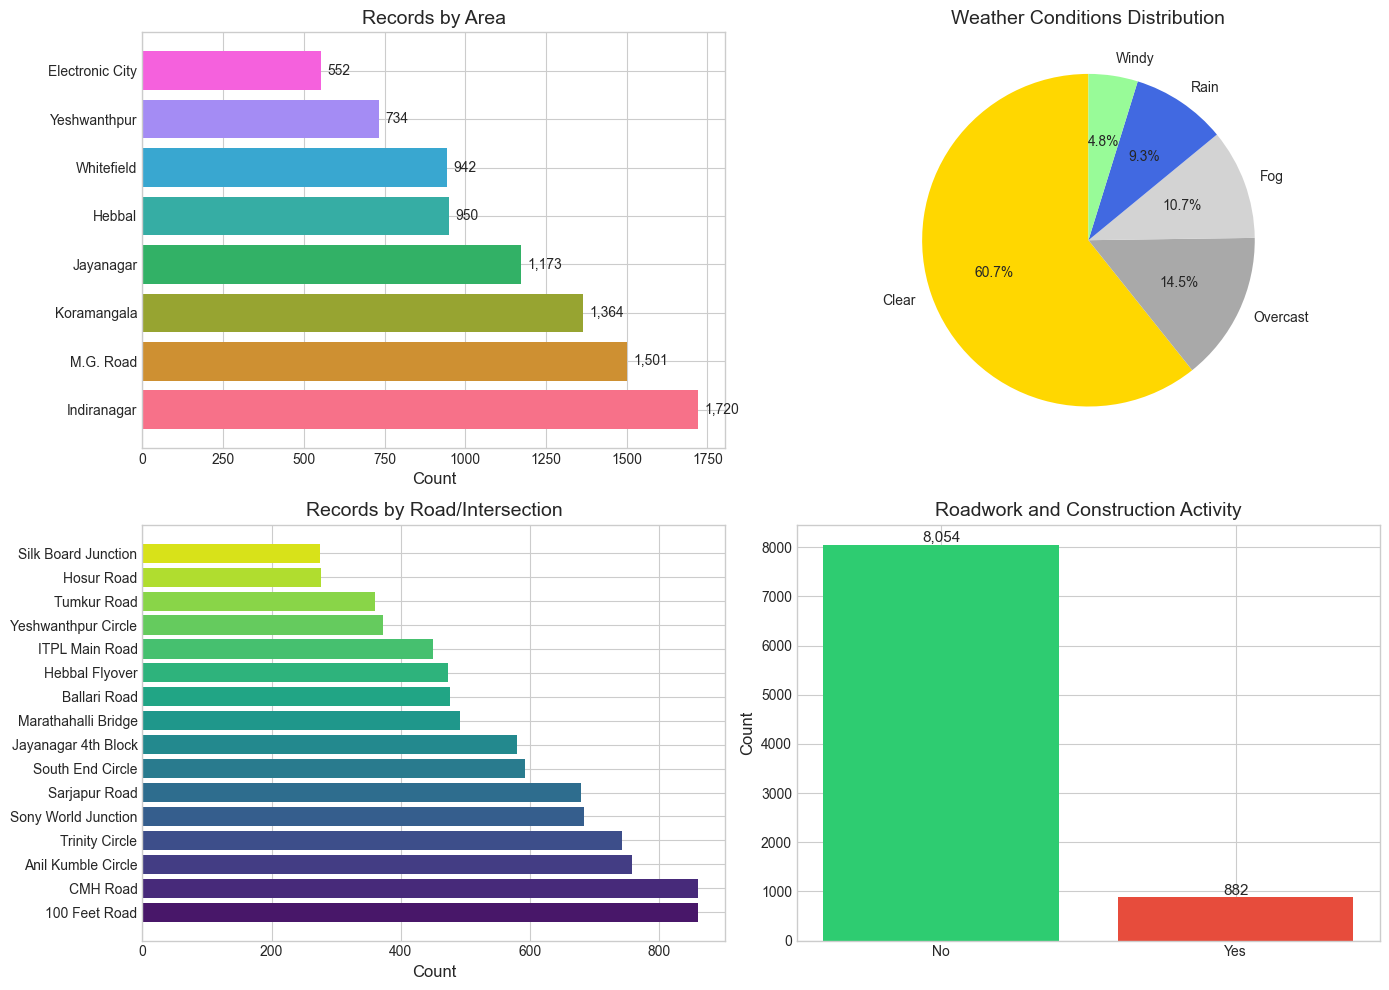

In [13]:
# Distribution of records by Area
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Area Name distribution
area_counts = df['Area Name'].value_counts()
axes[0, 0].barh(area_counts.index, area_counts.values, color=sns.color_palette('husl', len(area_counts)))
axes[0, 0].set_title('Records by Area', fontsize=TITLE_FONTSIZE)
axes[0, 0].set_xlabel('Count', fontsize=LABEL_FONTSIZE)
for i, v in enumerate(area_counts.values):
    axes[0, 0].text(v + 20, i, f'{v:,}', va='center', fontsize=10)

# Weather Conditions distribution
weather_counts = df['Weather Conditions'].value_counts()
colors = {'Clear': '#FFD700', 'Overcast': '#A9A9A9', 'Fog': '#D3D3D3', 'Rain': '#4169E1', 'Windy': '#98FB98'}
axes[0, 1].pie(weather_counts.values, labels=weather_counts.index, autopct='%1.1f%%',
               colors=[colors.get(w, '#ccc') for w in weather_counts.index], startangle=90)
axes[0, 1].set_title('Weather Conditions Distribution', fontsize=TITLE_FONTSIZE)

# Road/Intersection distribution
road_counts = df['Road/Intersection Name'].value_counts()
axes[1, 0].barh(road_counts.index, road_counts.values, color=sns.color_palette('viridis', len(road_counts)))
axes[1, 0].set_title('Records by Road/Intersection', fontsize=TITLE_FONTSIZE)
axes[1, 0].set_xlabel('Count', fontsize=LABEL_FONTSIZE)

# Roadwork distribution
roadwork_counts = df['Roadwork and Construction Activity'].value_counts()
axes[1, 1].bar(roadwork_counts.index, roadwork_counts.values, color=['#2ecc71', '#e74c3c'])
axes[1, 1].set_title('Roadwork and Construction Activity', fontsize=TITLE_FONTSIZE)
axes[1, 1].set_ylabel('Count', fontsize=LABEL_FONTSIZE)
for i, v in enumerate(roadwork_counts.values):
    axes[1, 1].text(i, v + 50, f'{v:,}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

### 4.2 Numerical Variables Distribution

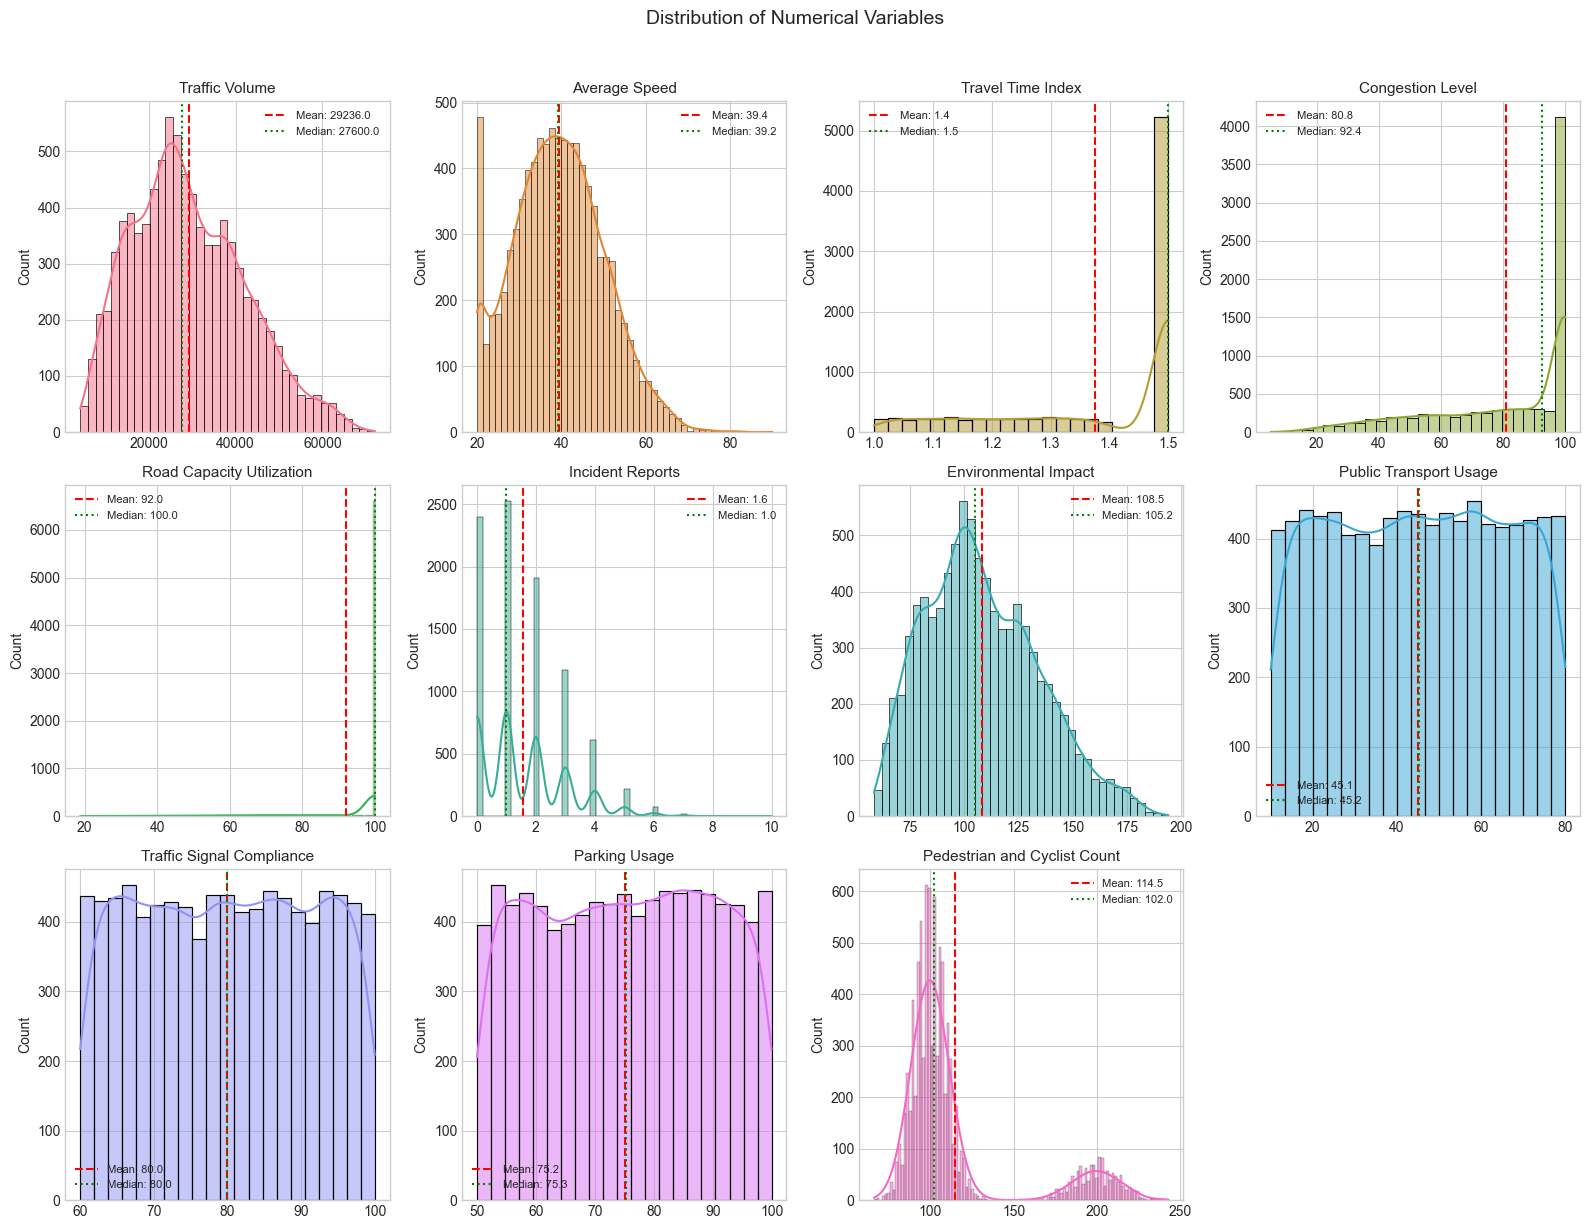

In [17]:
# Define numerical columns for analysis
numerical_cols = ['Traffic Volume', 'Average Speed', 'Travel Time Index', 
                  'Congestion Level', 'Road Capacity Utilization', 'Incident Reports',
                  'Environmental Impact', 'Public Transport Usage', 
                  'Traffic Signal Compliance', 'Parking Usage', 'Pedestrian and Cyclist Count']

# Distribution plots for key numerical variables
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

# Generate color palette
colors = sns.color_palette('husl', len(numerical_cols))

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    sns.histplot(df[col], kde=True, ax=ax, color=colors[idx])
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
    # Add mean and median lines
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='green', linestyle=':', linewidth=1.5, label=f'Median: {df[col].median():.1f}')
    ax.legend(fontsize=8)

# Hide empty subplot
axes[-1].axis('off')

plt.suptitle('Distribution of Numerical Variables', fontsize=TITLE_FONTSIZE, y=1.02)
plt.tight_layout()
plt.show()

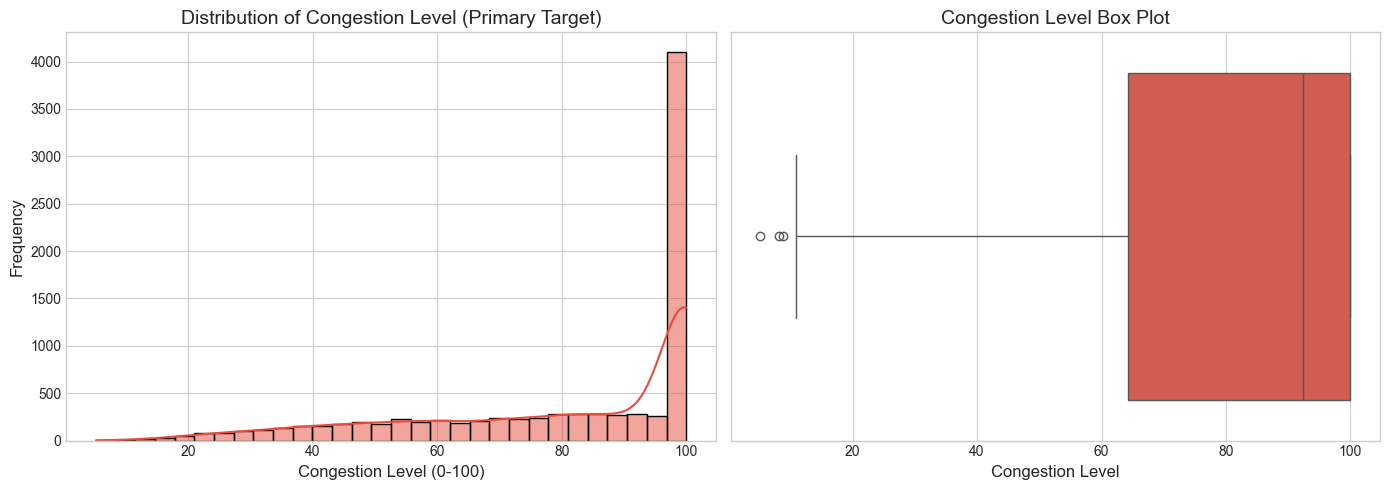

Congestion Level Statistics:
count   8936.00
mean      80.82
std       23.53
min        5.16
25%       64.29
50%       92.39
75%      100.00
max      100.00
Name: Congestion Level, dtype: float64


In [18]:
# Target variable deep dive: Congestion Level
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df['Congestion Level'], kde=True, ax=axes[0], color='#e74c3c', bins=30)
axes[0].set_title('Distribution of Congestion Level (Primary Target)', fontsize=TITLE_FONTSIZE)
axes[0].set_xlabel('Congestion Level (0-100)', fontsize=LABEL_FONTSIZE)
axes[0].set_ylabel('Frequency', fontsize=LABEL_FONTSIZE)

# Box plot
sns.boxplot(x=df['Congestion Level'], ax=axes[1], color='#e74c3c')
axes[1].set_title('Congestion Level Box Plot', fontsize=TITLE_FONTSIZE)
axes[1].set_xlabel('Congestion Level', fontsize=LABEL_FONTSIZE)

plt.tight_layout()
plt.show()

print(f"Congestion Level Statistics:")
print(df['Congestion Level'].describe())

---
## 5. Bivariate Analysis <a id='5-bivariate-analysis'></a>

### 5.1 Congestion Level by Categorical Variables

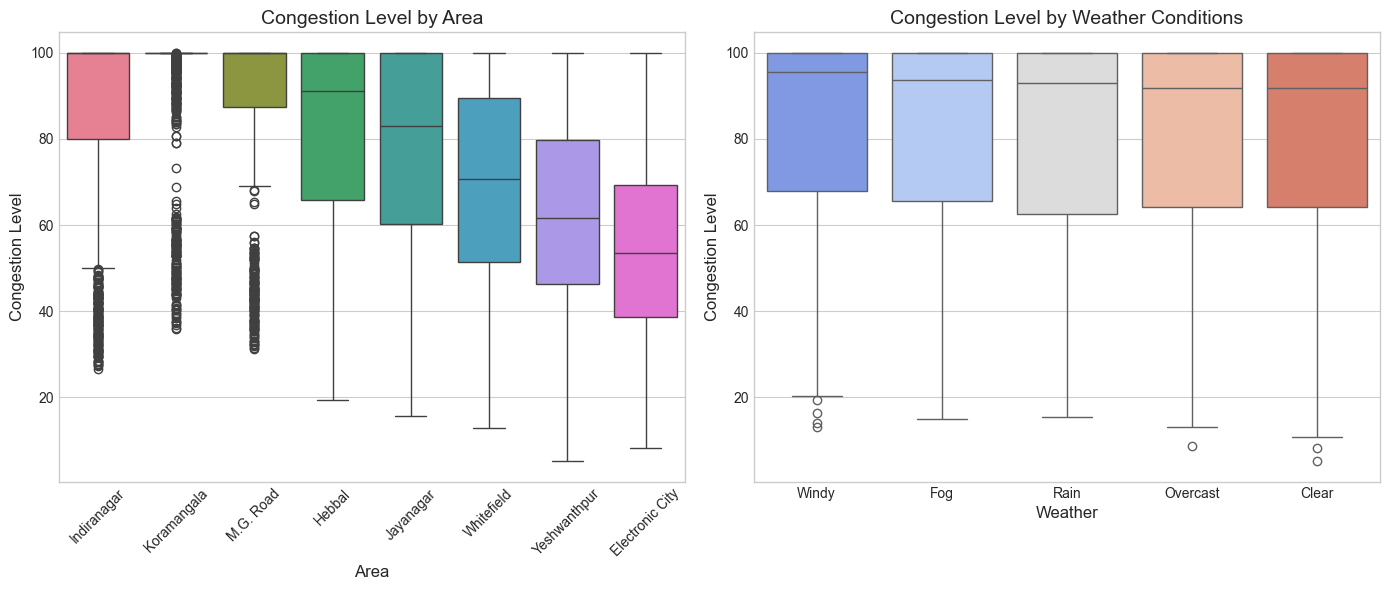

In [19]:
# Congestion Level by Area
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot by Area
area_order = df.groupby('Area Name')['Congestion Level'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Area Name', y='Congestion Level', order=area_order, ax=axes[0], palette='husl')
axes[0].set_title('Congestion Level by Area', fontsize=TITLE_FONTSIZE)
axes[0].set_xlabel('Area', fontsize=LABEL_FONTSIZE)
axes[0].set_ylabel('Congestion Level', fontsize=LABEL_FONTSIZE)
axes[0].tick_params(axis='x', rotation=45)

# Box plot by Weather
weather_order = df.groupby('Weather Conditions')['Congestion Level'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Weather Conditions', y='Congestion Level', order=weather_order, ax=axes[1], palette='coolwarm')
axes[1].set_title('Congestion Level by Weather Conditions', fontsize=TITLE_FONTSIZE)
axes[1].set_xlabel('Weather', fontsize=LABEL_FONTSIZE)
axes[1].set_ylabel('Congestion Level', fontsize=LABEL_FONTSIZE)

plt.tight_layout()
plt.show()

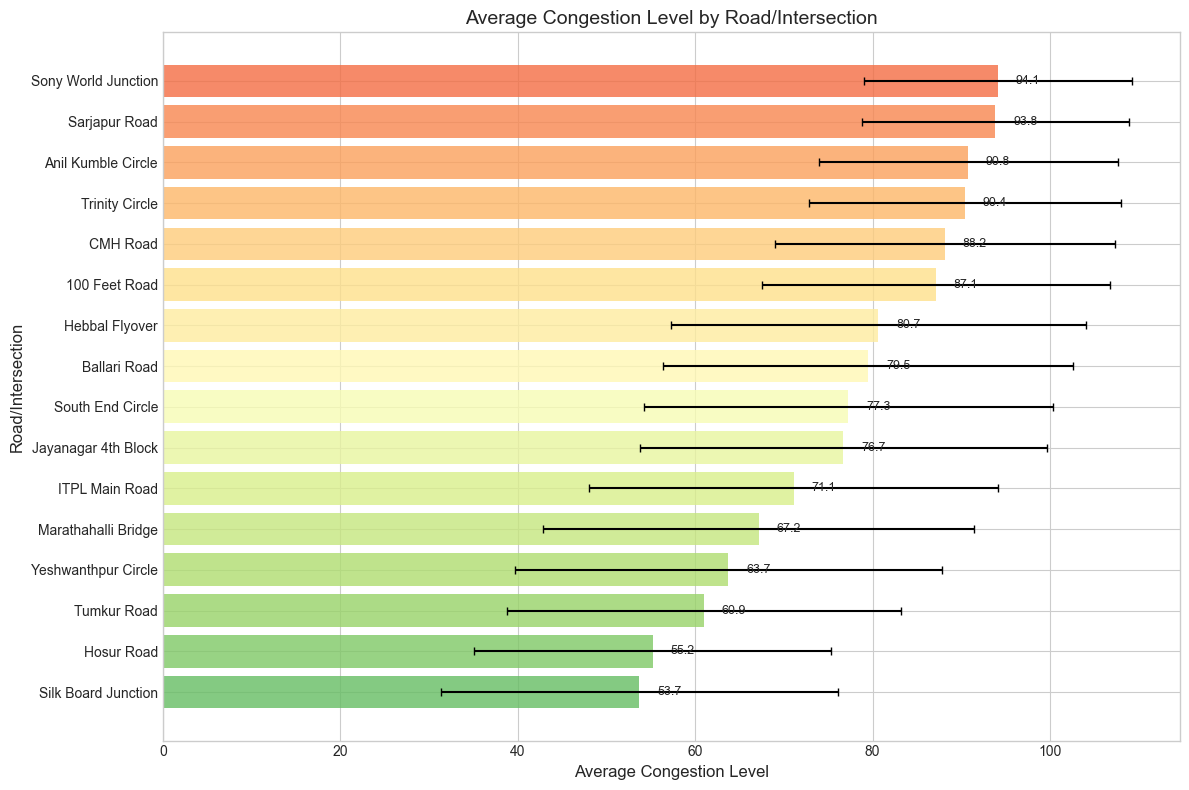

In [20]:
# Average Congestion by Road/Intersection
road_congestion = df.groupby('Road/Intersection Name')['Congestion Level'].agg(['mean', 'std']).sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(road_congestion)))
bars = ax.barh(road_congestion.index, road_congestion['mean'], xerr=road_congestion['std'], 
               color=colors, capsize=3, alpha=0.8)
ax.set_title('Average Congestion Level by Road/Intersection', fontsize=TITLE_FONTSIZE)
ax.set_xlabel('Average Congestion Level', fontsize=LABEL_FONTSIZE)
ax.set_ylabel('Road/Intersection', fontsize=LABEL_FONTSIZE)

# Add value labels
for bar, val in zip(bars, road_congestion['mean']):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 5.2 Relationship Between Key Variables

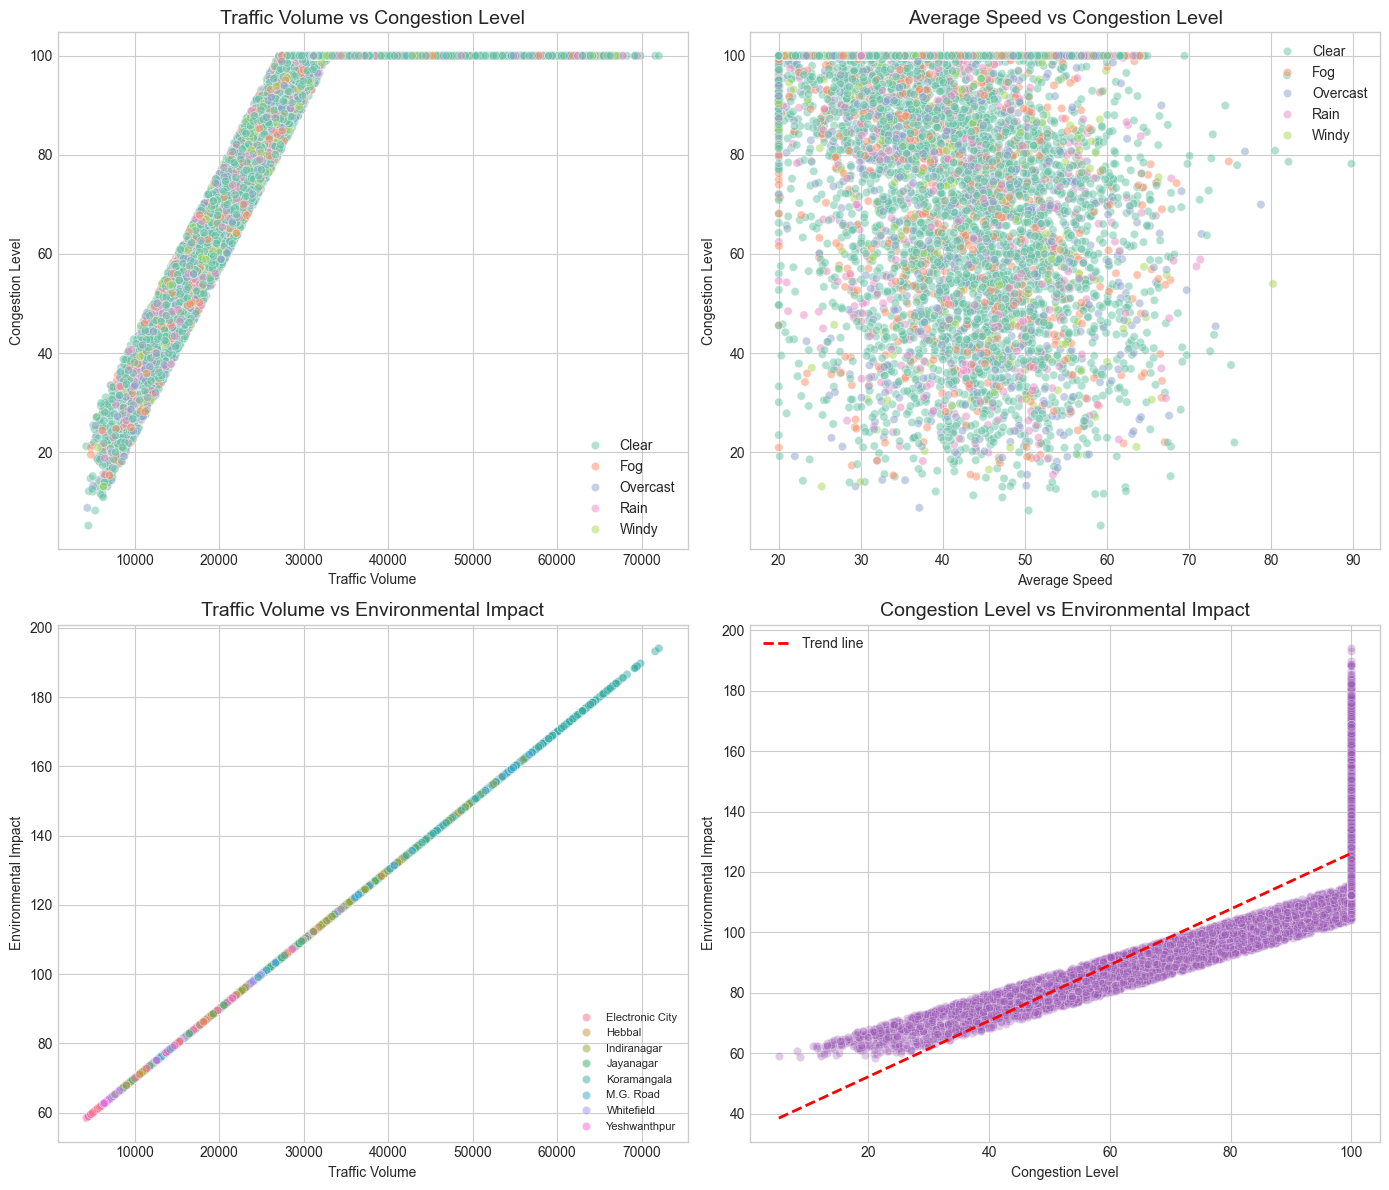

In [21]:
# Scatter plots: Traffic Volume vs Congestion Level
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Traffic Volume vs Congestion Level
sns.scatterplot(data=df, x='Traffic Volume', y='Congestion Level', hue='Weather Conditions', 
                alpha=0.5, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Traffic Volume vs Congestion Level', fontsize=TITLE_FONTSIZE)
axes[0, 0].legend(loc='lower right')

# Average Speed vs Congestion Level
sns.scatterplot(data=df, x='Average Speed', y='Congestion Level', hue='Weather Conditions',
                alpha=0.5, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Average Speed vs Congestion Level', fontsize=TITLE_FONTSIZE)
axes[0, 1].legend(loc='upper right')

# Traffic Volume vs Environmental Impact
sns.scatterplot(data=df, x='Traffic Volume', y='Environmental Impact', hue='Area Name',
                alpha=0.5, ax=axes[1, 0], palette='husl')
axes[1, 0].set_title('Traffic Volume vs Environmental Impact', fontsize=TITLE_FONTSIZE)
axes[1, 0].legend(loc='lower right', fontsize=8)

# Congestion Level vs Environmental Impact
sns.scatterplot(data=df, x='Congestion Level', y='Environmental Impact', alpha=0.3, ax=axes[1, 1], color='#9b59b6')
axes[1, 1].set_title('Congestion Level vs Environmental Impact', fontsize=TITLE_FONTSIZE)

# Add regression line
z = np.polyfit(df['Congestion Level'], df['Environmental Impact'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Congestion Level'].min(), df['Congestion Level'].max(), 100)
axes[1, 1].plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend line')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

---
## 6. Temporal Analysis <a id='6-temporal-analysis'></a>

In [22]:
# Extract temporal features for analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day_of_Week'] = df['Date'].dt.dayofweek
df['Day_Name'] = df['Date'].dt.day_name()
df['Is_Weekend'] = df['Day_of_Week'].isin([5, 6]).astype(int)
df['Quarter'] = df['Date'].dt.quarter
df['Day_of_Month'] = df['Date'].dt.day

print("Temporal features extracted:")
print(df[['Date', 'Year', 'Month', 'Day_of_Week', 'Day_Name', 'Is_Weekend', 'Quarter']].head())

Temporal features extracted:
        Date  Year  Month  Day_of_Week  Day_Name  Is_Weekend  Quarter
0 2022-01-01  2022      1            5  Saturday           1        1
1 2022-01-01  2022      1            5  Saturday           1        1
2 2022-01-01  2022      1            5  Saturday           1        1
3 2022-01-01  2022      1            5  Saturday           1        1
4 2022-01-01  2022      1            5  Saturday           1        1


In [23]:
# Congestion trends over time
daily_avg = df.groupby('Date')['Congestion Level'].mean().reset_index()

fig = px.line(daily_avg, x='Date', y='Congestion Level', 
              title='Daily Average Congestion Level Over Time',
              labels={'Congestion Level': 'Avg Congestion Level'})
fig.update_layout(xaxis_title='Date', yaxis_title='Average Congestion Level',
                  hovermode='x unified')
fig.add_hline(y=daily_avg['Congestion Level'].mean(), line_dash='dash', line_color='red',
              annotation_text=f"Overall Mean: {daily_avg['Congestion Level'].mean():.1f}")
fig.show()

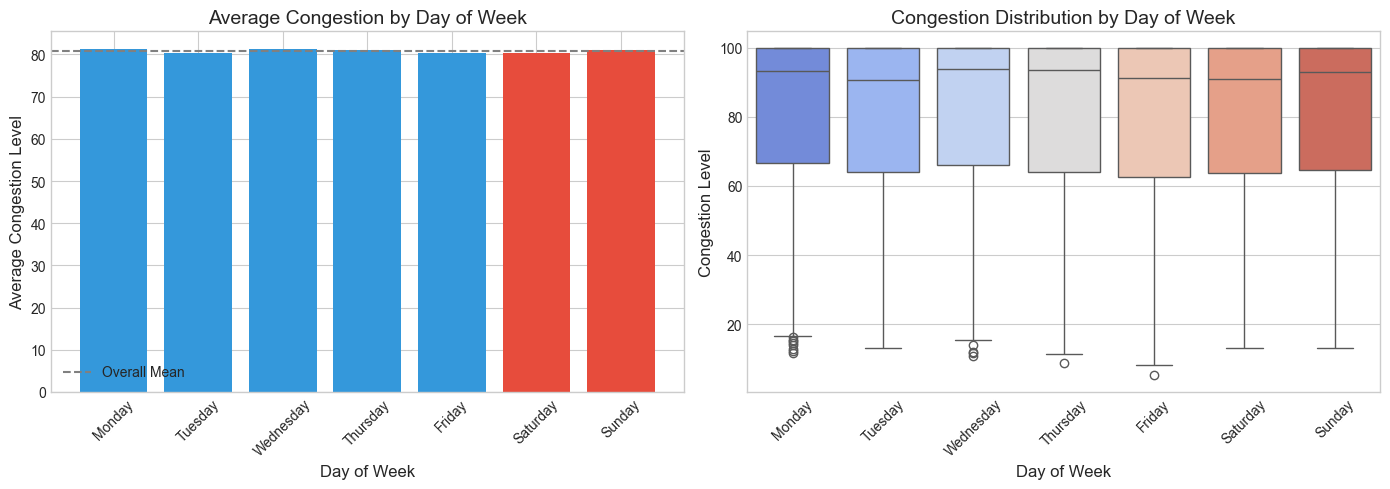

In [24]:
# Day of Week patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Order days correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Average congestion by day of week
dow_congestion = df.groupby('Day_Name')['Congestion Level'].mean().reindex(day_order)
colors = ['#e74c3c' if d in ['Saturday', 'Sunday'] else '#3498db' for d in day_order]
axes[0].bar(dow_congestion.index, dow_congestion.values, color=colors)
axes[0].set_title('Average Congestion by Day of Week', fontsize=TITLE_FONTSIZE)
axes[0].set_xlabel('Day of Week', fontsize=LABEL_FONTSIZE)
axes[0].set_ylabel('Average Congestion Level', fontsize=LABEL_FONTSIZE)
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=df['Congestion Level'].mean(), color='gray', linestyle='--', label='Overall Mean')
axes[0].legend()

# Box plot by day of week
sns.boxplot(data=df, x='Day_Name', y='Congestion Level', order=day_order, ax=axes[1], palette='coolwarm')
axes[1].set_title('Congestion Distribution by Day of Week', fontsize=TITLE_FONTSIZE)
axes[1].set_xlabel('Day of Week', fontsize=LABEL_FONTSIZE)
axes[1].set_ylabel('Congestion Level', fontsize=LABEL_FONTSIZE)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

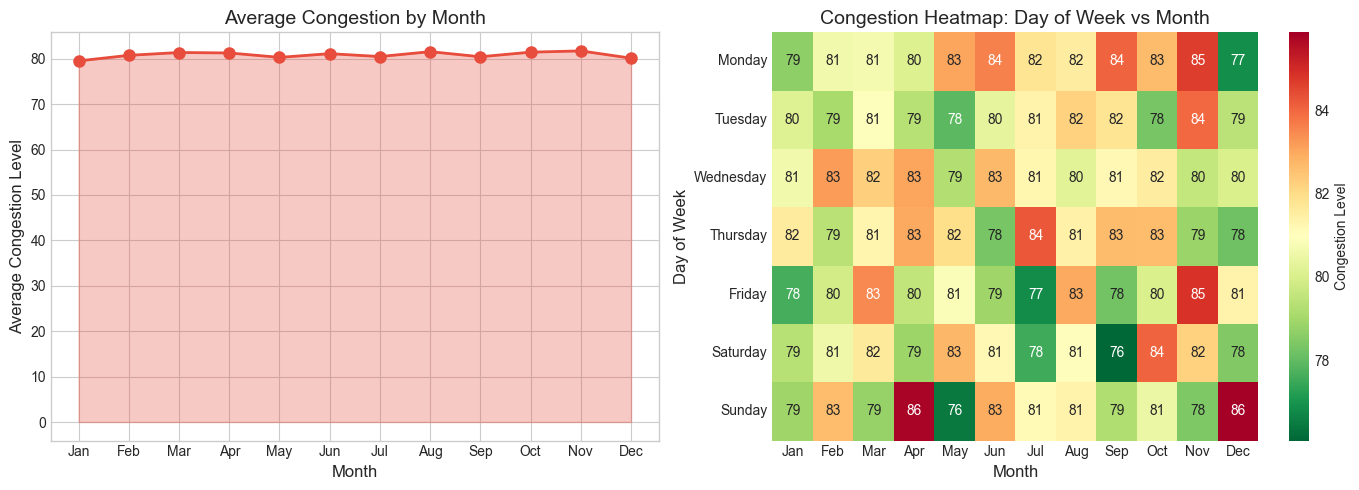

In [25]:
# Monthly patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average congestion by month
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_congestion = df.groupby('Month')['Congestion Level'].mean()
axes[0].plot(monthly_congestion.index, monthly_congestion.values, marker='o', linewidth=2, markersize=8, color='#e74c3c')
axes[0].fill_between(monthly_congestion.index, monthly_congestion.values, alpha=0.3, color='#e74c3c')
axes[0].set_title('Average Congestion by Month', fontsize=TITLE_FONTSIZE)
axes[0].set_xlabel('Month', fontsize=LABEL_FONTSIZE)
axes[0].set_ylabel('Average Congestion Level', fontsize=LABEL_FONTSIZE)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)

# Heatmap: Day of Week vs Month
pivot_table = df.pivot_table(values='Congestion Level', index='Day_Name', columns='Month', aggfunc='mean')
pivot_table = pivot_table.reindex(day_order)
sns.heatmap(pivot_table, cmap='RdYlGn_r', annot=True, fmt='.0f', ax=axes[1], cbar_kws={'label': 'Congestion Level'})
axes[1].set_title('Congestion Heatmap: Day of Week vs Month', fontsize=TITLE_FONTSIZE)
axes[1].set_xlabel('Month', fontsize=LABEL_FONTSIZE)
axes[1].set_ylabel('Day of Week', fontsize=LABEL_FONTSIZE)
axes[1].set_xticklabels(month_names)

plt.tight_layout()
plt.show()

---
## 7. Outlier Analysis <a id='7-outlier-analysis'></a>

In [26]:
def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Analyze outliers for key numerical columns
outlier_cols = ['Traffic Volume', 'Average Speed', 'Congestion Level', 
                'Environmental Impact', 'Incident Reports']

outlier_summary = []
for col in outlier_cols:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    outlier_summary.append({
        'Column': col,
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers) / len(df) * 100, 2),
        'Lower Bound': round(lb, 2),
        'Upper Bound': round(ub, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Column,Outlier Count,Outlier %,Lower Bound,Upper Bound
0,Traffic Volume,24,0.27,-8555.25,66026.75
1,Average Speed,33,0.37,9.47,68.95
2,Congestion Level,3,0.03,10.73,153.56
3,Environmental Impact,24,0.27,32.89,182.05
4,Incident Reports,100,1.12,-3.00,5.00


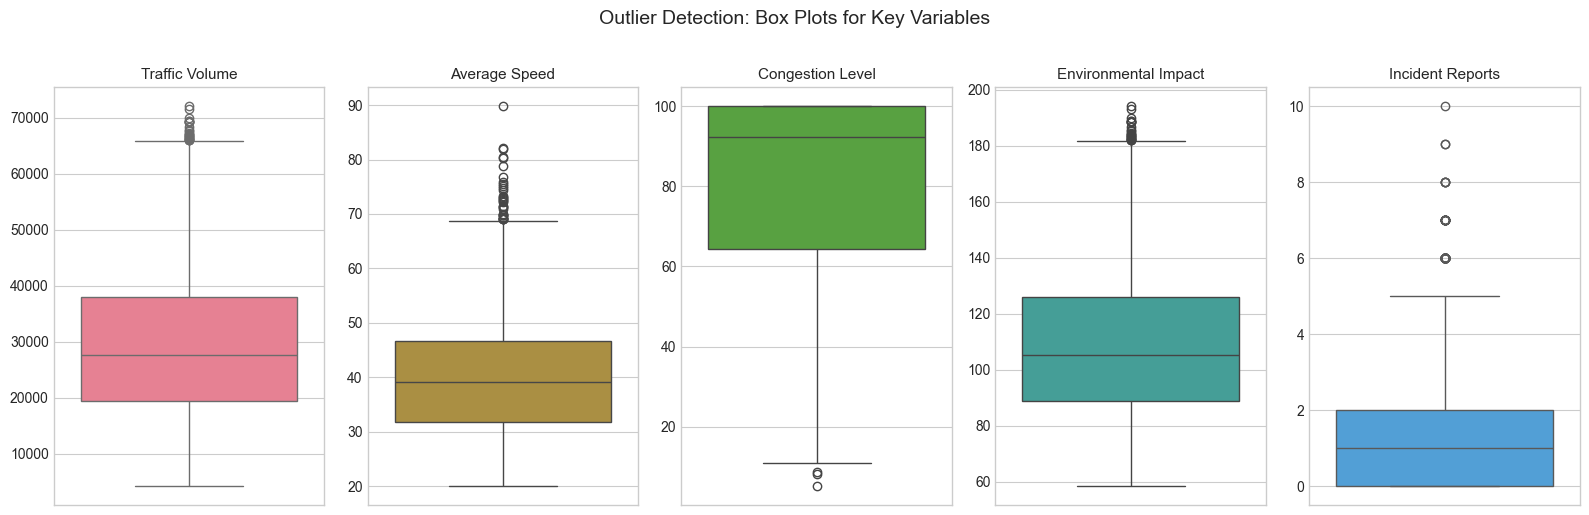

In [27]:
# Visualize outliers with box plots
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 5))

for idx, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[idx], color=sns.color_palette('husl')[idx])
    axes[idx].set_title(col, fontsize=11)
    axes[idx].set_ylabel('')

plt.suptitle('Outlier Detection: Box Plots for Key Variables', fontsize=TITLE_FONTSIZE, y=1.02)
plt.tight_layout()
plt.show()

In [28]:
# Investigate outliers in Congestion Level
congestion_outliers, lb, ub = detect_outliers_iqr(df, 'Congestion Level')
print(f"Congestion Level Outliers: {len(congestion_outliers)} records")
print(f"Lower bound: {lb:.2f}, Upper bound: {ub:.2f}")

if len(congestion_outliers) > 0:
    print("\nOutlier characteristics:")
    print(congestion_outliers[['Date', 'Area Name', 'Road/Intersection Name', 'Congestion Level', 
                               'Traffic Volume', 'Weather Conditions']].head(10))

Congestion Level Outliers: 3 records
Lower bound: 10.73, Upper bound: 153.56

Outlier characteristics:
           Date        Area Name Road/Intersection Name  Congestion Level  \
728  2022-03-18  Electronic City             Hosur Road              8.21   
3921 2023-02-23  Electronic City    Silk Board Junction              8.74   
6025 2023-10-06     Yeshwanthpur    Yeshwanthpur Circle              5.16   

      Traffic Volume Weather Conditions  
728             5292              Clear  
3921            4355           Overcast  
6025            4471              Clear  


### Outlier Handling Decision

Based on the analysis:
- **Congestion Level** outliers represent genuine low-congestion scenarios (not errors)
- **Traffic Volume** outliers are real high-traffic days
- **Incident Reports** outliers represent days with multiple incidents

**Decision:** Retain outliers as they represent valid real-world scenarios that the model should learn from.

---
## 8. Feature Engineering <a id='8-feature-engineering'></a>

In [29]:
# Sort data by Road and Date for lag feature creation
df = df.sort_values(['Road/Intersection Name', 'Date']).reset_index(drop=True)

# Create lag features (grouped by road)
lag_features = ['Traffic Volume', 'Congestion Level', 'Average Speed']

for col in lag_features:
    # Lag 1 (previous day)
    df[f'{col}_Lag1'] = df.groupby('Road/Intersection Name')[col].shift(1)
    
    # Lag 7 (same day last week)
    df[f'{col}_Lag7'] = df.groupby('Road/Intersection Name')[col].shift(7)
    
    # Rolling 7-day average
    df[f'{col}_Rolling7'] = df.groupby('Road/Intersection Name')[col].transform(
        lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
    )

print("Lag features created:")
print([col for col in df.columns if 'Lag' in col or 'Rolling' in col])

Lag features created:
['Traffic Volume_Lag1', 'Traffic Volume_Lag7', 'Traffic Volume_Rolling7', 'Congestion Level_Lag1', 'Congestion Level_Lag7', 'Congestion Level_Rolling7', 'Average Speed_Lag1', 'Average Speed_Lag7', 'Average Speed_Rolling7']


In [30]:
# Create additional derived features

# Speed to Volume ratio (efficiency metric)
df['Speed_Volume_Ratio'] = df['Average Speed'] / (df['Traffic Volume'] / 1000)

# Congestion per incident (impact metric)
df['Congestion_per_Incident'] = df['Congestion Level'] / (df['Incident Reports'] + 1)

# Road historical average congestion (baseline)
road_avg_congestion = df.groupby('Road/Intersection Name')['Congestion Level'].transform('mean')
df['Road_Avg_Congestion'] = road_avg_congestion

# Area historical average congestion
area_avg_congestion = df.groupby('Area Name')['Congestion Level'].transform('mean')
df['Area_Avg_Congestion'] = area_avg_congestion

# Deviation from road average
df['Congestion_Deviation'] = df['Congestion Level'] - df['Road_Avg_Congestion']

print("Derived features created:")
print(['Speed_Volume_Ratio', 'Congestion_per_Incident', 'Road_Avg_Congestion', 
       'Area_Avg_Congestion', 'Congestion_Deviation'])

Derived features created:
['Speed_Volume_Ratio', 'Congestion_per_Incident', 'Road_Avg_Congestion', 'Area_Avg_Congestion', 'Congestion_Deviation']


In [31]:
# Check for missing values after feature engineering (due to lag features)
missing_after = df.isnull().sum()
missing_after = missing_after[missing_after > 0]
print("Missing values after feature engineering:")
print(missing_after)

Missing values after feature engineering:
Traffic Volume_Lag1           16
Traffic Volume_Lag7          112
Traffic Volume_Rolling7       16
Congestion Level_Lag1         16
Congestion Level_Lag7        112
Congestion Level_Rolling7     16
Average Speed_Lag1            16
Average Speed_Lag7           112
Average Speed_Rolling7        16
dtype: int64


In [32]:
# Handle missing values from lag features
# Option: Drop rows with missing lag values (first few days per road)
df_clean = df.dropna(subset=[col for col in df.columns if 'Lag' in col or 'Rolling' in col])

print(f"Original shape: {df.shape}")
print(f"After dropping rows with missing lag values: {df_clean.shape}")
print(f"Rows removed: {len(df) - len(df_clean)} ({(len(df) - len(df_clean))/len(df)*100:.1f}%)")

Original shape: (8936, 37)
After dropping rows with missing lag values: (8824, 37)
Rows removed: 112 (1.3%)


In [33]:
# Final feature summary
print("=" * 60)
print("FINAL FEATURE SUMMARY")
print("=" * 60)

# Categorize features
target_vars = ['Congestion Level', 'Environmental Impact', 'Average Speed', 'Travel Time Index']

categorical_features = ['Area Name', 'Road/Intersection Name', 'Weather Conditions', 
                        'Roadwork and Construction Activity']

temporal_features = ['Year', 'Month', 'Day_of_Week', 'Day_Name', 'Is_Weekend', 'Quarter', 'Day_of_Month']

numerical_features = ['Traffic Volume', 'Road Capacity Utilization', 'Incident Reports',
                      'Public Transport Usage', 'Traffic Signal Compliance', 
                      'Parking Usage', 'Pedestrian and Cyclist Count']

lag_features_list = [col for col in df_clean.columns if 'Lag' in col or 'Rolling' in col]

derived_features = ['Speed_Volume_Ratio', 'Congestion_per_Incident', 'Road_Avg_Congestion',
                    'Area_Avg_Congestion', 'Congestion_Deviation']

print(f"\n1. TARGET VARIABLES ({len(target_vars)}):")
for f in target_vars:
    print(f"   - {f}")

print(f"\n2. CATEGORICAL FEATURES ({len(categorical_features)}):")
for f in categorical_features:
    print(f"   - {f}")

print(f"\n3. TEMPORAL FEATURES ({len(temporal_features)}):")
for f in temporal_features:
    print(f"   - {f}")

print(f"\n4. NUMERICAL FEATURES ({len(numerical_features)}):")
for f in numerical_features:
    print(f"   - {f}")

print(f"\n5. LAG FEATURES ({len(lag_features_list)}):")
for f in lag_features_list:
    print(f"   - {f}")

print(f"\n6. DERIVED FEATURES ({len(derived_features)}):")
for f in derived_features:
    print(f"   - {f}")

total_features = len(categorical_features) + len(temporal_features) + len(numerical_features) + len(lag_features_list) + len(derived_features)
print(f"\n{'='*60}")
print(f"TOTAL FEATURES FOR MODELING: {total_features}")
print(f"{'='*60}")

FINAL FEATURE SUMMARY

1. TARGET VARIABLES (4):
   - Congestion Level
   - Environmental Impact
   - Average Speed
   - Travel Time Index

2. CATEGORICAL FEATURES (4):
   - Area Name
   - Road/Intersection Name
   - Weather Conditions
   - Roadwork and Construction Activity

3. TEMPORAL FEATURES (7):
   - Year
   - Month
   - Day_of_Week
   - Day_Name
   - Is_Weekend
   - Quarter
   - Day_of_Month

4. NUMERICAL FEATURES (7):
   - Traffic Volume
   - Road Capacity Utilization
   - Incident Reports
   - Public Transport Usage
   - Traffic Signal Compliance
   - Parking Usage
   - Pedestrian and Cyclist Count

5. LAG FEATURES (9):
   - Traffic Volume_Lag1
   - Traffic Volume_Lag7
   - Traffic Volume_Rolling7
   - Congestion Level_Lag1
   - Congestion Level_Lag7
   - Congestion Level_Rolling7
   - Average Speed_Lag1
   - Average Speed_Lag7
   - Average Speed_Rolling7

6. DERIVED FEATURES (5):
   - Speed_Volume_Ratio
   - Congestion_per_Incident
   - Road_Avg_Congestion
   - Area_Avg_Conges

---
## 9. Correlation Analysis <a id='9-correlation-analysis'></a>

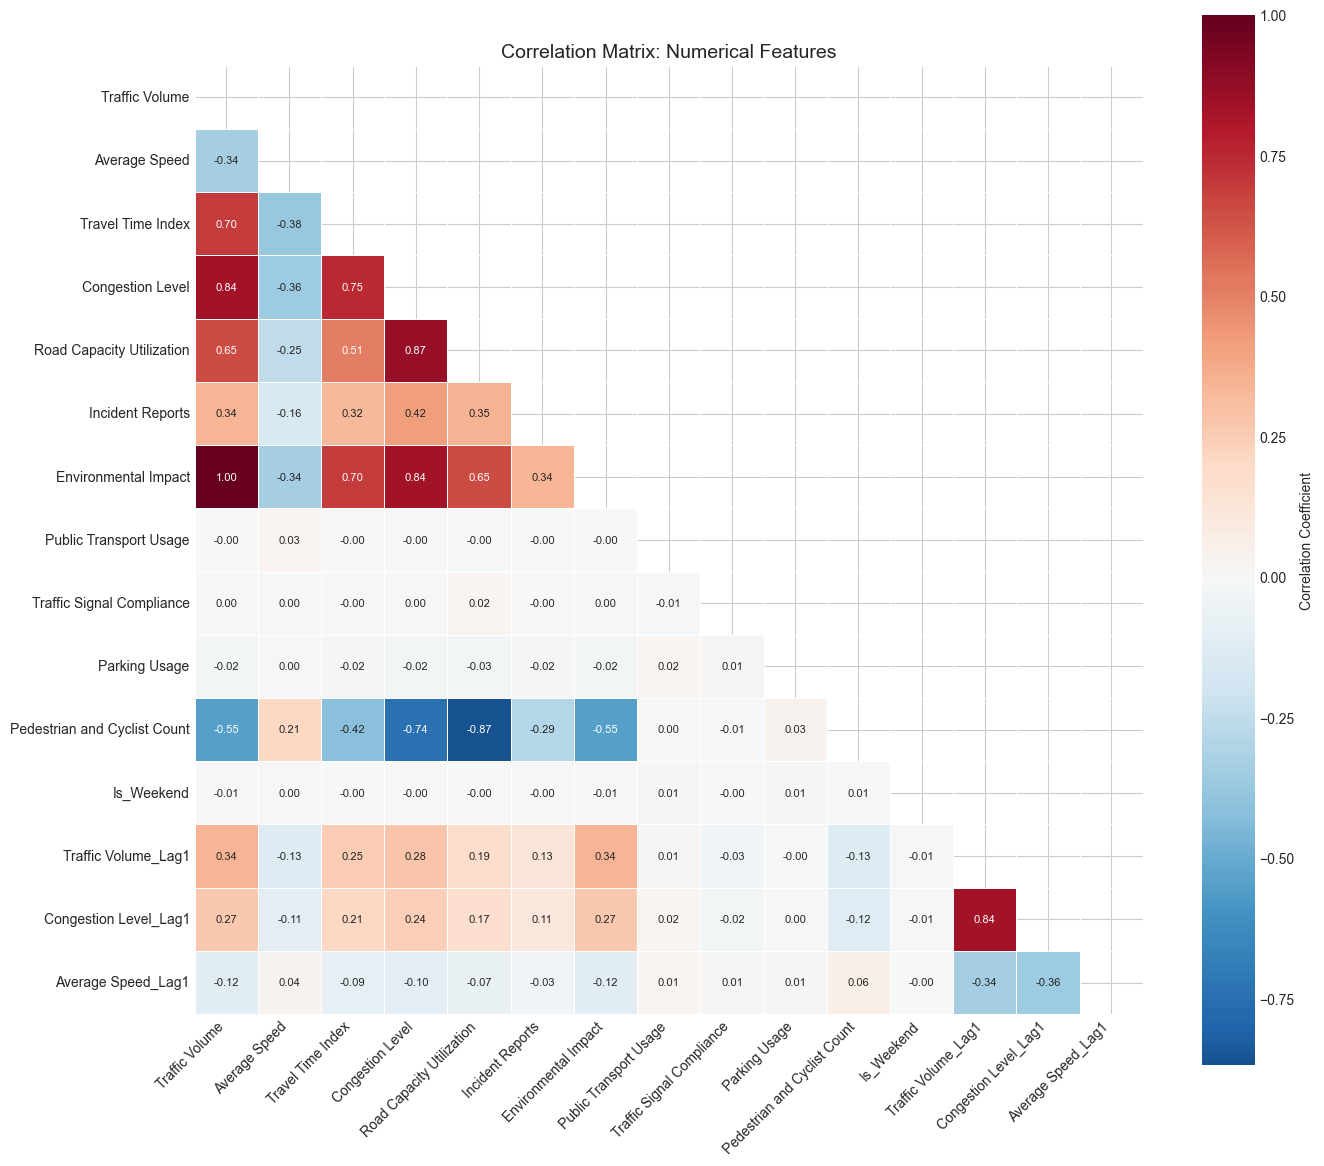

In [34]:
# Select numerical columns for correlation analysis
corr_cols = ['Traffic Volume', 'Average Speed', 'Travel Time Index', 'Congestion Level',
             'Road Capacity Utilization', 'Incident Reports', 'Environmental Impact',
             'Public Transport Usage', 'Traffic Signal Compliance', 'Parking Usage',
             'Pedestrian and Cyclist Count', 'Is_Weekend']

# Add lag features to correlation
corr_cols.extend([col for col in df_clean.columns if 'Lag1' in col])

corr_matrix = df_clean[corr_cols].corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 8},
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Correlation Matrix: Numerical Features', fontsize=TITLE_FONTSIZE)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

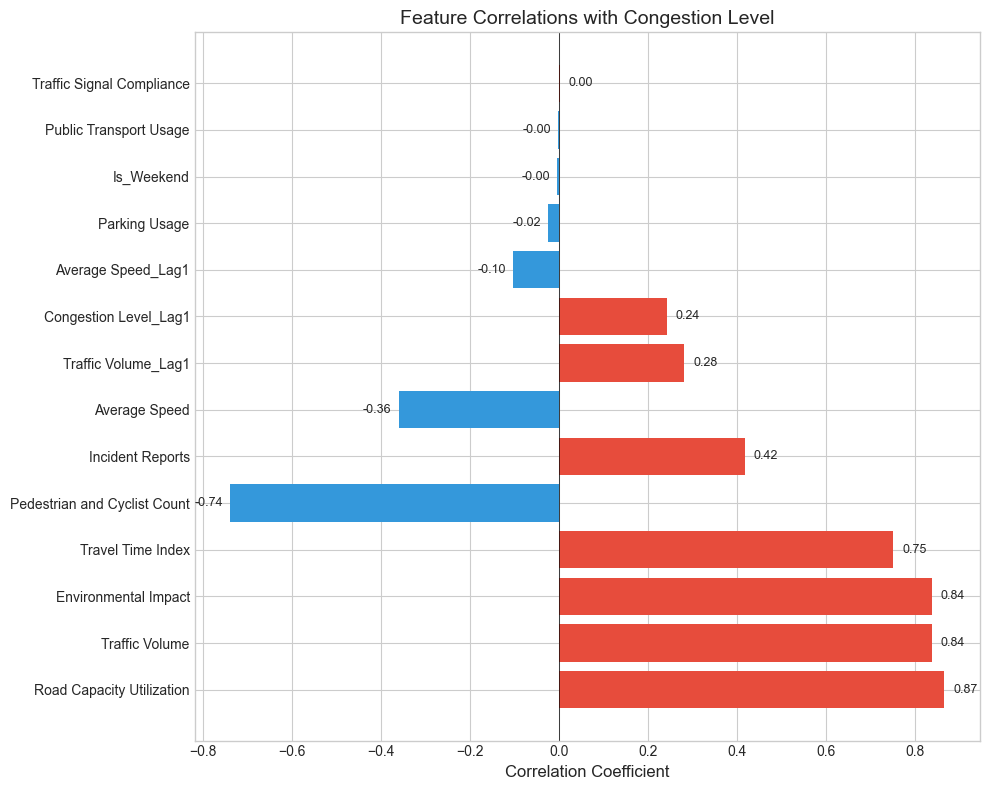


Top 5 Positive Correlations with Congestion Level:
Road Capacity Utilization       0.87
Traffic Volume                  0.84
Environmental Impact            0.84
Travel Time Index               0.75
Pedestrian and Cyclist Count   -0.74
Name: Congestion Level, dtype: float64

Top 5 Negative Correlations with Congestion Level:
Average Speed_Lag1          -0.10
Parking Usage               -0.02
Is_Weekend                  -0.00
Public Transport Usage      -0.00
Traffic Signal Compliance    0.00
Name: Congestion Level, dtype: float64


In [35]:
# Top correlations with target variable (Congestion Level)
target_corr = corr_matrix['Congestion Level'].drop('Congestion Level').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_title('Feature Correlations with Congestion Level', fontsize=TITLE_FONTSIZE)
ax.set_xlabel('Correlation Coefficient', fontsize=LABEL_FONTSIZE)
ax.axvline(x=0, color='black', linewidth=0.5)

# Add value labels
for bar, val in zip(bars, target_corr.values):
    ax.text(val + 0.02 if val > 0 else val - 0.08, bar.get_y() + bar.get_height()/2, 
            f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 5 Positive Correlations with Congestion Level:")
print(target_corr.head())
print("\nTop 5 Negative Correlations with Congestion Level:")
print(target_corr.tail())

---
## 10. Summary and Next Steps <a id='10-summary-and-next-steps'></a>

### Key Findings from EDA

**Data Quality:**
- ✓ No missing values in the original dataset
- ✓ No duplicate records
- ✓ All values within expected ranges
- ✓ Data types corrected appropriately

**Traffic Patterns Discovered:**
1. **Temporal Patterns:** Clear day-of-week and monthly seasonality in congestion levels
2. **Geographic Patterns:** Significant variation in congestion across different areas and roads
3. **Weather Impact:** Weather conditions show correlation with traffic patterns
4. **Strong Predictors:** Traffic Volume, Road Capacity Utilization, and lag features show strong correlation with Congestion Level

**Feature Engineering:**
- Created temporal features (day of week, month, weekend indicator)
- Created lag features (1-day, 7-day, rolling averages)
- Created derived features (speed-volume ratio, road averages)

### Recommended Model Approach

**Primary Target:** `Congestion Level` (regression problem)

**Baseline Model:** XGBoost Regressor
- Handles tabular data well
- Captures non-linear relationships
- Provides feature importance

**Evaluation Metrics:**
- **Primary:** RMSE (Root Mean Squared Error) - penalizes large errors
- **Secondary:** MAE (Mean Absolute Error) - interpretable in same units
- **R² Score** - explains variance captured by model

**Validation Strategy:** Time-Series Split (train on past, test on future)

In [36]:
# Save cleaned dataset for modeling
output_path = '../data/traffic_data_cleaned.csv'
df_clean.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path}")
print(f"Final shape: {df_clean.shape}")

Cleaned dataset saved to: ../data/traffic_data_cleaned.csv
Final shape: (8824, 37)


In [37]:
# Final dataset info
print("\n" + "="*60)
print("CLEANED DATASET SUMMARY")
print("="*60)
print(f"Total Records: {len(df_clean):,}")
print(f"Total Features: {len(df_clean.columns)}")
print(f"Date Range: {df_clean['Date'].min().strftime('%Y-%m-%d')} to {df_clean['Date'].max().strftime('%Y-%m-%d')}")
print(f"Areas Covered: {df_clean['Area Name'].nunique()}")
print(f"Roads Covered: {df_clean['Road/Intersection Name'].nunique()}")
print("="*60)


CLEANED DATASET SUMMARY
Total Records: 8,824
Total Features: 37
Date Range: 2022-01-08 to 2024-08-09
Areas Covered: 8
Roads Covered: 16
